In [1]:
import pandas as pd
import numpy as np
import os

In [5]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
c:\Users\nagen\OneDrive\ドキュメント\Mutual_Fund_Analytics\notebooks

Files/folders here:
['Advanced_Analytics.ipynb']


In [6]:
import os

processed_path = "../data/processed"

files = os.listdir(processed_path)

print("Processed files:")
for file in files:
    print(file)

Processed files:
01_fund_master.csv
02_nav_history_cleaned.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance_cleaned.csv
08_investor_transactions_cleaned.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv


In [7]:
for file in files:
    if file.lower().endswith(".csv"):
        path = os.path.join(processed_path, file)
        df = pd.read_csv(path)

        print(f"\n{'='*60}")
        print(file)
        print("Shape:", df.shape)
        print("Columns:", df.columns.tolist())


01_fund_master.csv
Shape: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

02_nav_history_cleaned.csv
Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']

03_aum_by_fund_house.csv
Shape: (90, 5)
Columns: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

04_monthly_sip_inflows.csv
Shape: (48, 6)
Columns: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

05_category_inflows.csv
Shape: (144, 3)
Columns: ['month', 'category', 'net_inflow_crore']

06_industry_folio_count.csv
Shape: (21, 6)
Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

07_scheme_performance_cleaned.csv
Shape: (40, 19)
Columns: ['amfi_co

In [8]:
# Load cleaned NAV history and fund master

nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

# Convert date
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort correctly before calculating returns
nav_df = nav_df.sort_values(["amfi_code", "date"])

print("NAV data:", nav_df.shape)
print("Number of schemes:", nav_df["amfi_code"].nunique())

display(nav_df.head())

NAV data: (46000, 3)
Number of schemes: 40


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
# Calculate daily returns for each scheme

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove the first row of each scheme where return is NaN
returns_df = nav_df.dropna(subset=["daily_return"]).copy()

print("Return records:", len(returns_df))
print("Schemes:", returns_df["amfi_code"].nunique())

display(
    returns_df[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(10)
)

Return records: 45960
Schemes: 40


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073
10,100016,2022-01-17,514.7627,0.000776


In [10]:
# Historical VaR (95%) and CVaR for all 40 schemes

risk_results = []

for amfi_code, group in returns_df.groupby("amfi_code"):
    
    returns = group["daily_return"].dropna()
    
    # 5th percentile = Historical VaR threshold
    var_95 = returns.quantile(0.05)
    
    # CVaR = mean of returns below VaR threshold
    cvar_95 = returns[returns <= var_95].mean()
    
    risk_results.append({
        "amfi_code": amfi_code,
        "VaR_95_daily": var_95,
        "CVaR_95_daily": cvar_95,
        "observations": len(returns)
    })

var_cvar_df = pd.DataFrame(risk_results)

# Add scheme names
var_cvar_df = var_cvar_df.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
var_cvar_df = var_cvar_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "VaR_95_daily",
        "CVaR_95_daily",
        "observations"
    ]
]

display(var_cvar_df.head())
print("\nNumber of schemes:", len(var_cvar_df))

,amfi_code,scheme_name,fund_house,category,VaR_95_daily,CVaR_95_daily,observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.014364,-0.018060,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,-0.003793,-0.004994,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,-0.019034,-0.023456,1149
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.013282,-0.017439,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.026021,-0.032459,1149



Number of schemes: 40


In [11]:
# Convert daily VaR/CVaR to percentage terms for readability

var_cvar_df["VaR_95_pct"] = var_cvar_df["VaR_95_daily"] * 100
var_cvar_df["CVaR_95_pct"] = var_cvar_df["CVaR_95_daily"] * 100

# Sort by VaR: most negative first
var_cvar_df = var_cvar_df.sort_values("VaR_95_daily")

# Save required deliverable
output_path = "../reports/var_cvar_report.csv"
var_cvar_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
display(var_cvar_df.head(10))

Saved: ../reports/var_cvar_report.csv


,amfi_code,scheme_name,fund_house,category,VaR_95_daily,CVaR_95_daily,observations,VaR_95_pct,CVaR_95_pct
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,-0.026859,-0.032384,1149,-2.685944,-3.238412
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,-0.026188,-0.031667,1149,-2.618842,-3.166729
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.026021,-0.032459,1149,-2.602125,-3.245906
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,-0.025438,-0.032304,1149,-2.543811,-3.230407
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,-0.024507,-0.030595,1149,-2.450705,-3.059526
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,-0.023483,-0.031036,1149,-2.348307,-3.103625
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-0.019220,-0.023251,1149,-1.922028,-2.325086
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,-0.019034,-0.023456,1149,-1.903354,-2.345576
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,-0.018892,-0.024342,1149,-1.889179,-2.434207
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,-0.018480,-0.024260,1149,-1.848028,-2.426006


In [12]:
# VaR & CVaR summary

print("VaR/CVaR Analysis Complete")
print(f"Number of schemes: {var_cvar_df['amfi_code'].nunique()}")
print(f"Total return observations: {len(returns_df):,}")

print("\nTop 5 funds by highest downside VaR:")
display(
    var_cvar_df[
        ["scheme_name", "VaR_95_pct", "CVaR_95_pct"]
    ].head(5)
)

VaR/CVaR Analysis Complete
Number of schemes: 40
Total return observations: 45,960

Top 5 funds by highest downside VaR:


,scheme_name,VaR_95_pct,CVaR_95_pct
22,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
17,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
4,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
11,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
21,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526


In [13]:
# Load scheme performance data
performance_df = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

# Select 5 key funds based on highest AUM
key_funds = (
    performance_df
    .sort_values("aum_crore", ascending=False)
    .head(5)[["amfi_code", "scheme_name", "aum_crore"]]
)

display(key_funds)

,amfi_code,scheme_name,aum_crore
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,49046
21,120842,Kotak Emerging Equity Fund - Regular - Growth,47469
17,118634,Nippon India Small Cap Fund - Regular - Growth,43630
37,149322,DSP Top 100 Equity Fund - Regular - Growth,41828
32,102886,UTI Mid Cap Fund - Regular - Growth,41728


In [14]:
# Calculate 90-day rolling Sharpe ratio for the 5 key funds

rolling_sharpe_list = []

for amfi_code in key_funds["amfi_code"]:
    
    fund_returns = (
        returns_df[returns_df["amfi_code"] == amfi_code]
        .sort_values("date")
        .set_index("date")["daily_return"]
    )
    
    rolling_sharpe = (
        fund_returns.rolling(90).mean()
        / fund_returns.rolling(90).std()
        * np.sqrt(252)
    )
    
    temp = rolling_sharpe.reset_index()
    temp.columns = ["date", "rolling_sharpe"]
    temp["amfi_code"] = amfi_code
    
    rolling_sharpe_list.append(temp)

rolling_sharpe_df = pd.concat(
    rolling_sharpe_list,
    ignore_index=True
)

rolling_sharpe_df = rolling_sharpe_df.merge(
    key_funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

display(rolling_sharpe_df.head())

,date,rolling_sharpe,amfi_code,scheme_name
0,2022-01-04,NaN,148568,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2022-01-05,NaN,148568,Mirae Asset Emerging Bluechip Fund - Regular -...
2,2022-01-06,NaN,148568,Mirae Asset Emerging Bluechip Fund - Regular -...
3,2022-01-07,NaN,148568,Mirae Asset Emerging Bluechip Fund - Regular -...
4,2022-01-10,NaN,148568,Mirae Asset Emerging Bluechip Fund - Regular -...


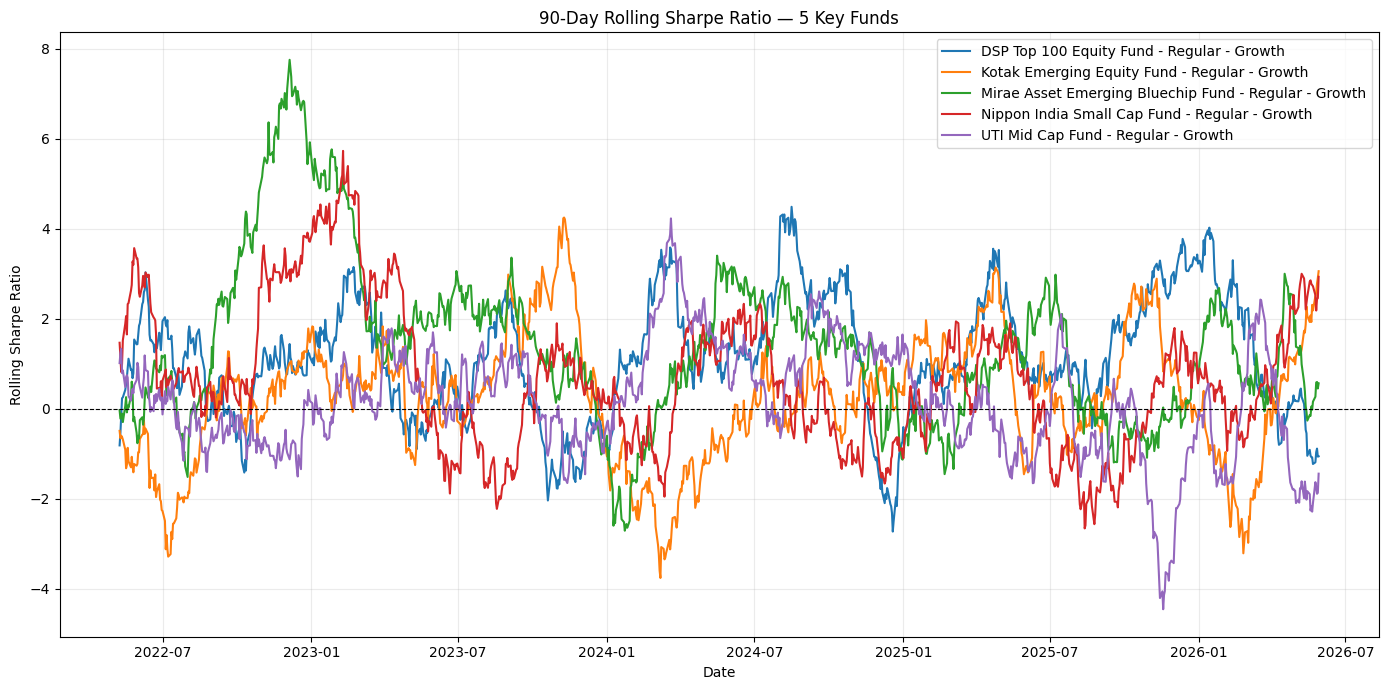

Saved: ../reports/rolling_sharpe_chart.png


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for scheme_name, group in rolling_sharpe_df.groupby("scheme_name"):
    plt.plot(
        group["date"],
        group["rolling_sharpe"],
        label=scheme_name,
        linewidth=1.5
    )

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.title("90-Day Rolling Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

chart_path = "../reports/rolling_sharpe_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {chart_path}")

In [16]:
# Load cleaned investor transactions

investor_df = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

investor_df["transaction_date"] = pd.to_datetime(
    investor_df["transaction_date"]
)

print("Shape:", investor_df.shape)
print("Unique investors:", investor_df["investor_id"].nunique())

display(investor_df.head())

Shape: (32778, 13)
Unique investors: 5000


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [17]:
# Find first transaction year for every investor

first_transaction = (
    investor_df
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["first_transaction_year"] = (
    first_transaction["transaction_date"].dt.year
)

display(first_transaction.head())

,investor_id,transaction_date,first_transaction_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [18]:
# Add cohort year to every transaction

investor_df = investor_df.merge(
    first_transaction[
        ["investor_id", "first_transaction_year"]
    ],
    on="investor_id",
    how="left"
)

display(
    investor_df[
        ["investor_id", "transaction_date", "first_transaction_year"]
    ].head(10)
)

,investor_id,transaction_date,first_transaction_year
0,INV003054,2024-01-01,2024
1,INV002952,2024-01-01,2024
2,INV003420,2024-01-01,2024
3,INV003436,2024-01-01,2024
4,INV004691,2024-01-01,2024
5,INV001497,2024-01-01,2024
6,INV000786,2024-01-01,2024
7,INV000616,2024-01-01,2024
8,INV003670,2024-01-01,2024
9,INV002054,2024-01-01,2024


In [19]:
# SIP transactions
sip_df = investor_df[
    investor_df["transaction_type"].str.upper() == "SIP"
].copy()

# Average SIP amount by investor cohort
avg_sip_by_cohort = (
    sip_df
    .groupby("first_transaction_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount_inr")
)

# Total invested by cohort
total_invested_by_cohort = (
    investor_df
    .groupby("first_transaction_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)

# Combine
cohort_summary = avg_sip_by_cohort.merge(
    total_invested_by_cohort,
    on="first_transaction_year",
    how="outer"
)

display(cohort_summary)

,first_transaction_year,avg_sip_amount_inr,total_invested_inr
0,2024,10996.885825,3491125187
1,2025,13505.209581,30455243


In [20]:
# Top fund preference for each investor cohort

cohort_fund_counts = (
    investor_df
    .groupby(["first_transaction_year", "amfi_code"])
    .size()
    .reset_index(name="transaction_count")
)

# Add scheme names
cohort_fund_counts = cohort_fund_counts.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Get the most-used fund for each cohort
top_funds_by_cohort = (
    cohort_fund_counts
    .sort_values(
        ["first_transaction_year", "transaction_count"],
        ascending=[True, False]
    )
    .groupby("first_transaction_year")
    .head(1)
    .reset_index(drop=True)
)

display(
    top_funds_by_cohort[
        [
            "first_transaction_year",
            "scheme_name",
            "transaction_count"
        ]
    ]
)

,first_transaction_year,scheme_name,transaction_count
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,SBI Small Cap Fund - Direct Plan - Growth,12


In [21]:
# Prepare SIP transactions for continuity analysis

sip_continuity = investor_df[
    investor_df["transaction_type"].str.upper() == "SIP"
].copy()

sip_continuity = sip_continuity.sort_values(
    ["investor_id", "transaction_date"]
)

print("SIP transactions:", len(sip_continuity))
print("Unique SIP investors:", sip_continuity["investor_id"].nunique())

SIP transactions: 19716
Unique SIP investors: 4762


In [22]:
# Calculate gap in days between consecutive SIP transactions

sip_continuity["gap_days"] = (
    sip_continuity
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

display(
    sip_continuity[
        ["investor_id", "transaction_date", "gap_days"]
    ].head(15)
)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [23]:
# Count SIP transactions per investor

sip_counts = (
    sip_continuity
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
]

print(
    "Investors with 6+ SIP transactions:",
    len(eligible_investors)
)

Investors with 6+ SIP transactions: 1362


In [24]:
# Calculate average SIP gap for eligible investors

sip_gap_summary = (
    sip_continuity[
        sip_continuity["investor_id"].isin(
            eligible_investors["investor_id"]
        )
    ]
    .groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

# Add transaction count
sip_gap_summary = sip_gap_summary.merge(
    eligible_investors,
    on="investor_id",
    how="left"
)

# Flag investors with average gap > 35 days
sip_gap_summary["status"] = np.where(
    sip_gap_summary["avg_gap_days"] > 35,
    "at-risk",
    "active"
)

display(
    sip_gap_summary.sort_values(
        "avg_gap_days",
        ascending=False
    ).head(20)
)

,investor_id,avg_gap_days,sip_transaction_count,status
506,INV001890,102.6,6,at-risk
323,INV001156,102.4,6,at-risk
1188,INV004296,102.2,6,at-risk
910,INV003325,101.0,6,at-risk
150,INV000522,100.8,6,at-risk
183,INV000608,100.2,6,at-risk
503,INV001883,99.2,6,at-risk
576,INV002166,99.2,6,at-risk
380,INV001367,99.0,6,at-risk
406,INV001491,98.8,6,at-risk


In [25]:
# Calculate SIP continuity statistics

total_eligible = len(sip_gap_summary)

at_risk_count = (
    sip_gap_summary["status"] == "at-risk"
).sum()

active_count = (
    sip_gap_summary["status"] == "active"
).sum()

continuity_rate = (
    active_count / total_eligible * 100
)

at_risk_rate = (
    at_risk_count / total_eligible * 100
)

print("SIP Continuity Analysis")
print("-" * 40)
print(f"Eligible investors (6+ SIPs): {total_eligible:,}")
print(f"Active/continuous investors: {active_count:,}")
print(f"At-risk investors: {at_risk_count:,}")
print(f"Continuity rate: {continuity_rate:.2f}%")
print(f"At-risk rate: {at_risk_rate:.2f}%")

SIP Continuity Analysis
----------------------------------------
Eligible investors (6+ SIPs): 1,362
Active/continuous investors: 30
At-risk investors: 1,332
Continuity rate: 2.20%
At-risk rate: 97.80%


In [26]:
# Load portfolio holdings

holdings_df = pd.read_csv(
    "../data/processed/09_portfolio_holdings.csv"
)

print("Shape:", holdings_df.shape)
print("Funds:", holdings_df["amfi_code"].nunique())
print("Sectors:", holdings_df["sector"].nunique())

display(holdings_df.head())

Shape: (322, 8)
Funds: 34
Sectors: 14


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [27]:
# Calculate sector-level weights and HHI for each fund

# Convert percentage weights to proportions
holdings_df["weight"] = holdings_df["weight_pct"] / 100

# Square each sector/stock weight
holdings_df["weight_squared"] = holdings_df["weight"] ** 2

# HHI = sum of squared weights for each fund
hhi_df = (
    holdings_df
    .groupby("amfi_code")["weight_squared"]
    .sum()
    .reset_index(name="sector_hhi")
)

# Add fund names and categories
hhi_df = hhi_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

# Sort from highest concentration to lowest
hhi_df = hhi_df.sort_values(
    "sector_hhi",
    ascending=False
)

print("Funds with HHI calculated:", len(hhi_df))

display(hhi_df.head(10))

Funds with HHI calculated: 34


,amfi_code,sector_hhi,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [28]:
# Correct Sector HHI calculation
# First aggregate stock weights within each sector,
# then calculate HHI = sum(sector_weight^2)

sector_weights = (
    holdings_df
    .groupby(["amfi_code", "sector"])["weight"]
    .sum()
    .reset_index(name="sector_weight")
)

sector_weights["sector_weight_squared"] = (
    sector_weights["sector_weight"] ** 2
)

sector_hhi_df = (
    sector_weights
    .groupby("amfi_code")["sector_weight_squared"]
    .sum()
    .reset_index(name="sector_hhi")
)

# Add fund details
sector_hhi_df = sector_hhi_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

# Equity funds only, as required
equity_hhi_df = (
    sector_hhi_df[
        sector_hhi_df["category"].str.contains(
            "Equity",
            case=False,
            na=False
        )
    ]
    .sort_values("sector_hhi", ascending=False)
)

print("Equity funds:", len(equity_hhi_df))

display(equity_hhi_df.head(10))

Equity funds: 34


,amfi_code,sector_hhi,scheme_name,category
11,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Equity
30,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
27,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
6,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,Equity
32,149323,0.241077,DSP Midcap Fund - Regular - Growth,Equity
21,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth,Equity
10,118635,0.237497,Nippon India ETF Nifty 50 BeES,Equity
18,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth,Equity
22,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity


## Advanced Analytics — Key Insights

### 1. Historical VaR & CVaR
SBI Small Cap Fund - Direct Plan - Growth recorded the highest 95% historical daily VaR at approximately -2.69%, indicating the largest downside loss threshold among the 40 schemes analyzed. Its CVaR was approximately -3.24%, showing that losses in the worst 5% of daily observations were more severe on average.

### 2. Investor Cohort Analysis
The 2024 investor cohort had substantially higher total invested value (₹349.11 crore) than the 2025 cohort (₹3.05 crore). However, the average SIP amount was higher for the 2025 cohort at approximately ₹13,505 compared with approximately ₹10,997 for the 2024 cohort.

### 3. SIP Continuity
Among 1,362 investors with at least six SIP transactions, only 30 were classified as active/continuous based on an average SIP gap of 35 days or less. This resulted in a SIP continuity rate of 2.20%, while 97.80% were classified as at-risk under the defined >35-day average-gap rule.

### 4. Fund Recommendation by Risk Appetite
The recommender identified liquid funds as the top Low-risk recommendations, with ICICI Pru Liquid Fund having the highest Sharpe ratio of 7.68. For Moderate risk, HDFC Top 100 Fund and Mirae Asset Large Cap Fund had the highest Sharpe ratio of 1.06. For High risk, Kotak Emerging Equity Fund ranked first with a Sharpe ratio of 0.96.

### 5. Sector Concentration
Axis Bluechip Fund - Regular - Growth had the highest sector HHI among the equity funds analyzed, with an HHI of approximately 0.297. This indicates the highest sector concentration within the analyzed equity-fund portfolios and highlights greater exposure concentration compared with funds having lower HHI values.